# Finance MRAG (Multi-step RAG) Pipeline

**파이프라인 구조:**
```
Query
    ↓
Rewrite       ← 질문을 검색에 최적화된 형태로 재작성
    ↓
Retrieve      ← Pinecone(finance-bok / bok-ns1)에서 관련 문서 검색
    ↓
Grade         ← 검색된 문서의 관련성 평가
    ├─ good   → Generate → 답변 출력
    ├─ bad (retry < 2) → rewrite_retry → Retrieve (루프)
    └─ bad (retry >= 2) → Fallback → 경고 포함 답변 출력
```

| 항목 | 내용 |
|------|------|
| 문서 | 2026년 2월 한국은행 경제전망보고서 (93페이지, 249청크) |
| 벡터 DB | Pinecone `finance-bok` / `bok-ns1` |
| 임베딩 | `text-embedding-3-small` (1536차원) |
| LLM | `gpt-4o-mini` (temperature=0) |
| LangGraph | 1.1.6 |

## 1. 임포트 및 환경변수 설정

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

print("API 키 로드 완료")

API 키 로드 완료


## 2. Pinecone / Embedding / LLM 초기화

In [3]:
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_pinecone import PineconeVectorStore
from langchain_core.output_parsers import StrOutputParser

# 임베딩 모델
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

vectorstore = PineconeVectorStore.from_existing_index(
    index_name="finance-bok",
    embedding=embeddings,
    namespace="bok-ns1"
)
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

# LLM
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
    )
parser = StrOutputParser()

print("LLM / Retriever 초기화 완료")

LLM / Retriever 초기화 완료


## 3. LangGraph State 정의

In [4]:
from typing import TypedDict, List
from langchain_core.documents import Document

class MRAGState(TypedDict):
    """MRAG 파이프라인 전체 상태"""
    query:          str            # 사용자 원본 질문
    rewritten:      str            # 재작성된 검색 질문
    docs:           List[Document] # 검색된 문서 청크
    doc_grade:      str            # 'good' | 'bad'
    answer:         str            # 최종 답변
    retry_count:    int            # 재시도 횟수 (최대 2회)
    fallback_used:  bool           # Fallback 경로 사용 여부

## 4. 노드(Node) 함수 정의

### Node 1 :Rewrite -  질문 재작성

In [5]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# ─── Node 1 : Rewrite ───────────────────────────────────────────────────
rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system", """당신은 금융 검색 전문가입니다.
사용자의 질문을 한국은행 경제전망 보고서 검색에 최적화된 형태로 재작성하세요.
재작성된 질문만 출력하세요."""),
    ('human', '원본 질문: {query}')
])
rewrite_chain = rewrite_prompt | llm | parser

def node_rewrite(state: MRAGState) -> dict:
    rewritten = rewrite_chain.invoke({'query': state['query']})
    print(f"[Rewrite] '{state['query']}' → '{rewritten}'")
    return {'rewritten': rewritten}

### Node 2 : Retrieve — 문서 검색

In [6]:
# ─── Node 2 : Retrieve ──────────────────────────────────────────────────
def node_retrieve(state: MRAGState) -> dict:
    docs = retriever.invoke(state['rewritten'])
    print(f"[Retrieve] {len(docs)}개 청크 검색됨 (retry={state.get('retry_count', 0)})")
    return {'docs': docs}

### Node 3 : Grade — 문서 품질 평가

In [7]:
# ─── Node 3 : Grade ─────────────────────────────────────────────────────
grade_prompt = ChatPromptTemplate.from_messages([
    ("system", """당신은 검색 문서의 품질을 평가하는 전문가입니다.
아래 질문과 검색된 문서를 보고 문서가 질문에 답변하기에 충분한지 평가하세요.
충분하면 "good", 불충분하면 "bad"만 출력하세요."""),
    ("human", """질문: {query}

검색된 문서:
{context}""")
])
grade_chain = grade_prompt | llm | parser

def node_grade(state: MRAGState) -> dict:
    context = '\n\n---\n\n'.join(d.page_content for d in state['docs'])
    result  = grade_chain.invoke({'query': state['query'], 'context': context})
    grade   = 'good' if 'good' in result.lower() else 'bad'
    print(f"[Grade] → {grade}  (raw='{result.strip()}')")
    return {'doc_grade': grade}

###  Node 4a : Generate 

In [9]:
rewrite_retry_prompt = ChatPromptTemplate.from_messages([
    ('system',
     '당신은 금융·경제 문서 검색 전문가입니다.\n'
     '이전 검색이 불충분했습니다. 다른 관점의 키워드나 동의어를 활용해 '
     '더 효과적인 검색 쿼리를 작성하세요.\n'
     '재작성된 쿼리만 출력하세요.'),
    ('human',
     '원본 질문: {query}\n'
     '이전 쿼리: {rewritten}')
])
rewrite_retry_chain = rewrite_retry_prompt | llm | parser

def node_rewrite_retry(state: MRAGState) -> dict:
    new_query = rewrite_retry_chain.invoke({
        'query':     state['query'],
        'rewritten': state['rewritten'],
    })
    count = state.get('retry_count', 0) + 1
    print(f"[Rewrite-Retry #{count}] '{new_query}'")
    return {'rewritten': new_query, 'retry_count': count}

### Node 4b : Rewrite Retry 

In [10]:
rewrite_retry_prompt = ChatPromptTemplate.from_messages([
    ('system',
     '당신은 금융·경제 문서 검색 전문가입니다.\n'
     '이전 검색이 불충분했습니다. 다른 관점의 키워드나 동의어를 활용해 '
     '더 효과적인 검색 쿼리를 작성하세요.\n'
     '재작성된 쿼리만 출력하세요.'),
    ('human',
     '원본 질문: {query}\n'
     '이전 쿼리: {rewritten}')
])
rewrite_retry_chain = rewrite_retry_prompt | llm | parser

def node_rewrite_retry(state: MRAGState) -> dict:
    new_query = rewrite_retry_chain.invoke({
        'query':     state['query'],
        'rewritten': state['rewritten'],
    })
    count = state.get('retry_count', 0) + 1
    print(f"[Rewrite-Retry #{count}] '{new_query}'")
    return {'rewritten': new_query, 'retry_count': count}

###  Node 4c : Fallback 

In [30]:
# ─── Node 4c : Fallback ─────────────────────────────────────────────────
fallback_prompt = ChatPromptTemplate.from_messages([
    ('system',
     '관련 문서를 찾지 못했습니다. '
     '답변을 만들어내지 말고 "해당 내용은 보고서에서 확인되지 않습니다"라고만 답하세요.'),
    ('human', '질문: {query}')
])
fallback_chain = fallback_prompt | llm | parser

def node_fallback(state: MRAGState) -> dict:
    answer = fallback_chain.invoke({'query': state['query']})
    print('[Fallback] 답변 생성')
    return {'answer': answer, 'fallback_used': True}

print('모든 노드 함수 정의 완료')

모든 노드 함수 정의 완료


## 5. 조건부 엣지(Conditional Edge) 정의

In [31]:
MAX_RETRY = 2

def route_after_grade(state: MRAGState) -> str:
    '''
    Grade 노드 이후 분기:
      - good              → 'generate'
      - bad + retry < 2   → 'rewrite_retry'
      - bad + retry >= 2  → 'fallback'
    '''
    if state['doc_grade'] == 'good':
        return 'generate'
    if state.get('retry_count', 0) < MAX_RETRY:
        return 'rewrite_retry'
    return 'fallback'

print(f'라우터 정의 완료  (MAX_RETRY={MAX_RETRY})')

라우터 정의 완료  (MAX_RETRY=2)


## 6. LangGraph 그래프 구성

그래프 컴파일 완료


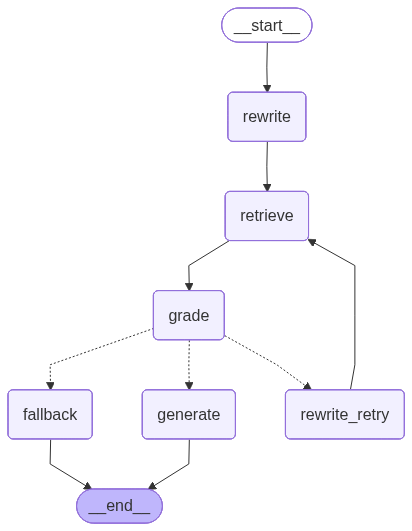

In [32]:
from langgraph.graph import StateGraph, START, END

# 그래프 초기화
graph = StateGraph(MRAGState)

# 노드 등록
graph.add_node("rewrite",       node_rewrite)
graph.add_node("retrieve",      node_retrieve)
graph.add_node("grade",         node_grade)
graph.add_node("generate",      node_generate)
graph.add_node("rewrite_retry", node_rewrite_retry)
graph.add_node("fallback",      node_fallback)

# 엣지 연결
graph.add_edge(START,      "rewrite")
graph.add_edge("rewrite",  "retrieve")
graph.add_edge("retrieve", "grade")

# Grade → 분기 (good / bad-retry / bad-fallback)
graph.add_conditional_edges(
    "grade",
    route_after_grade,
    {
        "generate":      "generate",
        "rewrite_retry": "rewrite_retry",
        "fallback":      "fallback",
    }
)

# Retry 루프: rewrite_retry → retrieve
graph.add_edge("rewrite_retry", "retrieve")

# 종료 엣지
graph.add_edge("generate", END)
graph.add_edge("fallback",  END)

# 컴파일
app = graph.compile()
print("그래프 컴파일 완료")
app

## 7. 실행 헬퍼 함수

In [33]:
from IPython.display import Markdown, display

def run_mrag(query: str) -> dict:
    """MRAG 파이프라인 실행 후 최종 상태 반환"""
    initial_state: MRAGState = {
        "query":         query,
        "rewritten":     "",
        "docs":          [],
        "doc_grade":     "",
        "answer":        "",
        "retry_count":   0,
        "fallback_used": False,
    }
    print(f"\n{'='*60}")
    print(f"질문: {query}")
    print(f"{'='*60}")
    final_state = app.invoke(initial_state)
    print(f"{'='*60}")
    print(f"Fallback 사용: {final_state['fallback_used']} | 재시도: {final_state['retry_count']}회")
    return final_state

def display_answer(state: dict):
    """최종 답변을 Markdown으로 출력"""
    display(Markdown(f"### 답변\n\n{state['answer']}"))

print('헬퍼 함수 정의 완료')

헬퍼 함수 정의 완료


## 8. 테스트 실행

In [34]:
# 테스트 1: 성장률 질문
state1 = run_mrag("2026년 GDP 성장률 전망치는 얼마인가요?")
display_answer(state1)


질문: 2026년 GDP 성장률 전망치는 얼마인가요?
[Rewrite] '2026년 GDP 성장률 전망치는 얼마인가요?' → '2026년 GDP 성장률에 대한 한국은행의 경제전망 보고서는 어떻게 되나요?'
[Retrieve] 4개 청크 검색됨 (retry=0)
[Grade] → bad  (raw='bad')
[Rewrite-Retry #1] '2026년 한국 GDP 성장률 예측에 대한 최신 경제 전망은 무엇인가요?'
[Retrieve] 4개 청크 검색됨 (retry=1)
[Grade] → good  (raw='good')
[Generate] 답변 생성 완료 (27자)
Fallback 사용: False | 재시도: 1회


### 답변

2026년 GDP 성장률 전망치는 2.0%입니다.

In [35]:
# 테스트 2: 물가 질문
state2 = run_mrag("2026년 소비자물가 상승률 전망과 주요 상방·하방 리스크는 무엇인가요?")
display_answer(state2)


질문: 2026년 소비자물가 상승률 전망과 주요 상방·하방 리스크는 무엇인가요?
[Rewrite] '2026년 소비자물가 상승률 전망과 주요 상방·하방 리스크는 무엇인가요?' → '2026년 소비자물가 상승률 전망 및 주요 상방·하방 리스크는 무엇인지 한국은행 경제전망 보고서에서 확인할 수 있나요?'
[Retrieve] 4개 청크 검색됨 (retry=0)
[Grade] → bad  (raw='bad')
[Rewrite-Retry #1] '2026년 소비자물가 상승률 예측과 주요 리스크 요인(상방 및 하방)에 대한 정보는 한국은행의 경제 전망 보고서에서 찾을 수 있을까요?'
[Retrieve] 4개 청크 검색됨 (retry=1)
[Grade] → bad  (raw='bad')
[Rewrite-Retry #2] '2026년 소비자물가 상승률 전망 및 주요 리스크 요인(상방과 하방)에 대한 정보는 한국은행의 경제 전망 보고서나 관련 경제 분석 자료에서 확인할 수 있을까요?'
[Retrieve] 4개 청크 검색됨 (retry=2)
[Grade] → bad  (raw='bad')
[Fallback] 답변 생성
Fallback 사용: True | 재시도: 2회


### 답변

해당 내용은 보고서에서 확인되지 않습니다.

In [36]:
# 테스트 3: 없는 질문
state3 = run_mrag("2030년 한국 부동산 시장 전망은?")
display_answer(state3)


질문: 2030년 한국 부동산 시장 전망은?
[Rewrite] '2030년 한국 부동산 시장 전망은?' → '2030년 한국은행 경제전망 보고서에서 제시하는 한국 부동산 시장 전망은 무엇인가요?'
[Retrieve] 4개 청크 검색됨 (retry=0)
[Grade] → bad  (raw='bad')
[Rewrite-Retry #1] '2030년 한국 부동산 시장 예측 및 한국은행 경제 전망 분석은 어떻게 되나요?'
[Retrieve] 4개 청크 검색됨 (retry=1)
[Grade] → bad  (raw='bad')
[Rewrite-Retry #2] '2030년 한국 부동산 시장 동향 및 한국 경제 전망에 대한 분석은 어떤가요?'
[Retrieve] 4개 청크 검색됨 (retry=2)
[Grade] → bad  (raw='bad')
[Fallback] 답변 생성
Fallback 사용: True | 재시도: 2회


### 답변

해당 내용은 보고서에서 확인되지 않습니다.

In [37]:
# 테스트 3: 배치 실행
questions = [
    "한국은행의 기준금리 전망은?",
    "수출 증가율 전망치와 주요 불확실성 요인은?",
    "가계부채 현황과 금융안정 리스크 평가는?",
]

results = []
for q in questions:
    s = run_mrag(q)
    results.append(s)
    display_answer(s)


질문: 한국은행의 기준금리 전망은?
[Rewrite] '한국은행의 기준금리 전망은?' → '한국은행 경제전망 보고서에서 기준금리 전망은 어떻게 제시되고 있나요?'
[Retrieve] 4개 청크 검색됨 (retry=0)
[Grade] → bad  (raw='bad')
[Rewrite-Retry #1] '한국은행의 기준금리 예측 및 경제 전망에 대한 최신 정보는 무엇인가요?'
[Retrieve] 4개 청크 검색됨 (retry=1)
[Grade] → bad  (raw='bad')
[Rewrite-Retry #2] '한국은행의 기준금리 전망 및 경제 동향에 대한 최근 분석은 무엇인가요?'
[Retrieve] 4개 청크 검색됨 (retry=2)
[Grade] → bad  (raw='bad')
[Fallback] 답변 생성
Fallback 사용: True | 재시도: 2회


### 답변

해당 내용은 보고서에서 확인되지 않습니다.


질문: 수출 증가율 전망치와 주요 불확실성 요인은?
[Rewrite] '수출 증가율 전망치와 주요 불확실성 요인은?' → '한국은행 경제전망 보고서에서 수출 증가율 전망치와 관련된 주요 불확실성 요인은 무엇인가요?'
[Retrieve] 4개 청크 검색됨 (retry=0)
[Grade] → bad  (raw='bad')
[Rewrite-Retry #1] '한국은행 경제전망 보고서에서 수출 성장률 예측과 관련된 주요 리스크 요인은 무엇인지 알아보세요.'
[Retrieve] 4개 청크 검색됨 (retry=1)
[Grade] → bad  (raw='bad')
[Rewrite-Retry #2] '한국은행 경제전망 보고서에서 수출 성장률 예측과 관련된 주요 위험 요소 및 불확실성 요인은 무엇인지 조사해 보세요.'
[Retrieve] 4개 청크 검색됨 (retry=2)
[Grade] → bad  (raw='bad')
[Fallback] 답변 생성
Fallback 사용: True | 재시도: 2회


### 답변

해당 내용은 보고서에서 확인되지 않습니다.


질문: 가계부채 현황과 금융안정 리스크 평가는?
[Rewrite] '가계부채 현황과 금융안정 리스크 평가는?' → '가계부채 현황 및 금융안정 리스크 평가에 대한 한국은행 경제전망 보고서 내용은 무엇인가요?'
[Retrieve] 4개 청크 검색됨 (retry=0)
[Grade] → bad  (raw='bad')
[Rewrite-Retry #1] '가계부채 현황과 금융안정 위험 분석에 대한 한국은행의 경제 전망 및 관련 보고서는 어떤 내용을 포함하고 있나요?'
[Retrieve] 4개 청크 검색됨 (retry=1)
[Grade] → bad  (raw='bad')
[Rewrite-Retry #2] '가계부채 현황 및 금융안정성 리스크 평가에 대한 한국은행의 경제 전망과 관련된 보고서의 주요 내용은 무엇인가요?'
[Retrieve] 4개 청크 검색됨 (retry=2)
[Grade] → bad  (raw='bad')
[Fallback] 답변 생성
Fallback 사용: True | 재시도: 2회


### 답변

해당 내용은 보고서에서 확인되지 않습니다.

## 10. 결과 요약

In [38]:
import pandas as pd

all_states = [state1, state2] + results
summary = pd.DataFrame([
    {
        "질문":         s["query"][:40] + "...",
        "재작성 쿼리":  s["rewritten"][:40] + "...",
        "검색 청크 수": len(s["docs"]),
        "최종 Grade":  s["doc_grade"],
        "재시도 횟수":  s["retry_count"],
        "Fallback":    s["fallback_used"],
        "답변 길이":    len(s["answer"]),
    }
    for s in all_states
])

display(summary)

,질문,재작성 쿼리,검색 청크 수,최종 Grade,재시도 횟수,Fallback,답변 길이
0,2026년 GDP 성장률 전망치는 얼마인가요?...,2026년 한국 GDP 성장률 예측에 대한 최신 경제 전망은 무엇인가요?...,4,good,1,False,27
1,2026년 소비자물가 상승률 전망과 주요 상방·하방 리스크는 무엇인가요?...,2026년 소비자물가 상승률 전망 및 주요 리스크 요인(상방과 하방)에 ...,4,bad,2,True,23
2,한국은행의 기준금리 전망은?...,한국은행의 기준금리 전망 및 경제 동향에 대한 최근 분석은 무엇인가요?...,4,bad,2,True,23
3,수출 증가율 전망치와 주요 불확실성 요인은?...,한국은행 경제전망 보고서에서 수출 성장률 예측과 관련된 주요 위험 요소 ...,4,bad,2,True,23
4,가계부채 현황과 금융안정 리스크 평가는?...,가계부채 현황 및 금융안정성 리스크 평가에 대한 한국은행의 경제 전망과 ...,4,bad,2,True,23
